In [62]:
import os
import sys
import yaml
import zarr
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno

from plotnine import *
from IPython.display import display

In [102]:
gene_name = "APOB" #APOB
# gene_id = "ENSG00000130164" #LDLR

phenotype = 'ldl_direct_int'

olink_path = '/home/dnanexus/data_dir/olink/olink_corrected_rint_90_pcs.parquet'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
anngeno_path = '/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag'
annotation_file= '/home/dnanexus/data_dir/genebass1e6_genes_10kb_allvars_annotated_250925.parquet'

pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int.parquet'
cov_path = '/home/dnanexus/data_dir/phenotypes/250709_quant_phenotypes_covariates_genetic_pcs_prs_corrected.parquet'

config_path = f'/home/dnanexus/ukbgym/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)

# exp_data_path = '/home/dnanexus/data_dir/exp_data/BRCA1_BRCA2_SGE_combined_new.parquet'
save_path = None

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
all_annotation_list

['loftee_hc',
 'cadd_raw',
 'am_pathogenicity',
 'esmscoremissense',
 'gpn_score',
 'zooverphylop',
 'verphylop']

In [115]:
id_cols = ['id', 'region', 'gene_name']
annotation_df = pl.scan_parquet(annotation_file).filter(pl.col('gene_name') == gene_name)

columns = id_cols + all_annotation_list
existing_annos = [c for c in all_annotation_list if c in annotation_df.collect_schema().names()]

annotation_df = annotation_df.select(set(id_cols).union(set(existing_annos))).collect(engine='streaming')
gene_id = annotation_df['region'].unique().item()
print(f"Filtering annotations dataframe for {gene_name} - {gene_id}")

melted_anno = annotation_df.unpivot(
    index=id_cols,
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)
melted_anno

Filtering annotations dataframe for APOB - ENSG00000084674


id,region,gene_name,annotation,annotation_score
str,str,str,str,f32
"""chr2:21035577:G:A""","""ENSG00000084674""","""APOB""","""loftee_hc""",0.0
"""chr2:21029016:T:C""","""ENSG00000084674""","""APOB""","""loftee_hc""",0.0
"""chr2:21042116:G:C""","""ENSG00000084674""","""APOB""","""loftee_hc""",0.0
"""chr2:21036905:C:A""","""ENSG00000084674""","""APOB""","""loftee_hc""",0.0
"""chr2:21044070:G:T""","""ENSG00000084674""","""APOB""","""loftee_hc""",0.0
…,…,…,…,…
"""chr2:20998187:TATC:T""","""ENSG00000084674""","""APOB""","""verphylop""",0.042
"""chr2:21042977:TGAA:T""","""ENSG00000084674""","""APOB""","""verphylop""",0.042
"""chr2:21027306:A:ATTTTTTTTTTTTT…","""ENSG00000084674""","""APOB""","""verphylop""",0.042


In [116]:
sample_ids = zarr.open(f'{anngeno_path}/zarr_store/samples', mode='r')[:]
var_ids = pl.read_parquet(f'{anngeno_path}/variant_metadata.parquet', columns=['id'])['id'].to_numpy()
geno = zarr.open(f'{anngeno_path}/zarr_store/genotypes', mode='r')

eur_samples = pl.read_csv(eur_samples_path).rename({'eid': 'individual'}).with_columns(
    pl.col("individual").cast(pl.Utf8)
)['individual'].to_list()

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.


In [117]:
@numba.njit(parallel=True, fastmath=True)
def _fast_clip_and_sum_allels(arr):
    # Get the shape of the input array
    # Using specific dimensions for clarity with this problem
    n_samples, n_variants, _ = arr.shape
    
    # The sum of two positive int8s can be up to 254. 
    # An int16 is a safe and fast output type.
    output = np.empty((n_samples, n_variants), dtype=np.int8)
    
    # Numba's prange enables automatic parallelization across all your CPU cores
    for i in numba.prange(n_samples):
        for j in range(n_variants):
            # Read two values, perform logic, write one value.
            # This is the "fused" operation.
            val1 = arr[i, j, 0]
            val2 = arr[i, j, 1]
            
            s = 0
            # Since input is int8, this check is faster than max(0, val)
            if val1 > 0:
                s += val1
            if val2 > 0:
                s += val2
            
            output[i, j] = s
            
    return output

def process_genotype_chunk(
    geno: np.array, 
    var_ids: np.array, 
    sample_list: np.array,
    melted_pheno_df: pl.LazyFrame,
    homozygous: bool = False,
    debug: bool = False,
) -> pl.LazyFrame:
    """
    Extract genotypes for a specific gene and return as lazy DataFrame
    """
    geno_clipped = _fast_clip_and_sum_allels(geno)
    # Find heterozygous genotypes (genotype == 1)
    rows, cols = np.where(geno_clipped == 1)
    geno_melt = pl.DataFrame({
        'id': var_ids[rows],
        'individual': sample_list[cols],
        'genotype': 1
    })
    
    # Find homozygous genotypes (genotype == 2)
    if homozygous:
        rows, cols = np.where(geno_clipped == 2)
        hom = pl.DataFrame({
            'id': var_ids[rows],
            'individual': sample_list[cols],
            'genotype': 2
        })
        geno_melt = pl.concat([geno_melt, hom])

    var_pheno_df = geno_melt.lazy().join(melted_pheno_df, on='individual', how='left').collect(engine='streaming')
    return var_pheno_df

# ------------------------ Load Olink data and filter to EUR samples ------------------------
olink_df = pl.read_parquet(olink_path, columns=['sample', gene_id]).rename({'sample': 'individual'}).filter(
    pl.col("individual").is_in(eur_samples)
).fill_nan(None)

olink_melt = (
    olink_df.unpivot(
        index=['individual'],
        on=[gene_id],
        variable_name='olink_gene',
        value_name='olink_value',
    )
)
print(f"Olink individuals: {olink_melt['individual'].n_unique()}")

# ------------------------ Optimized approach to find indices of olink_samples in sample_ids ------------------------
# Step A: Create a lookup dictionary mapping each ID in the large array to its original index. This takes O(N) time, where N is the size of sample_ids.
olink_sids = olink_df['individual'].to_numpy()
sample_id_to_index = {sid: i for i, sid in enumerate(sample_ids)}

# Step B: Iterate through the smaller array and find the index for each element if it exists in our lookup dictionary. This takes O(M) time, where M is the size of olink_sids.
found_indices = []
for sid in olink_sids:
    if sid in sample_id_to_index:
        found_indices.append(sample_id_to_index[sid])
print(f"Found {len(found_indices)} matching sample IDs.")

# Step C: Convert the list of indices to a NumPy array and sort it. Sorting ensures the output is identical to the original np.where approach, which returns indices in ascending order.
olink_indices = np.sort(found_indices)

# ------------------------ Find variants to keep based on olink_var_ids ------------------------
# Step A:
olink_var_ids = pl.scan_parquet(annotation_file).filter(pl.col('region')==gene_id).select(['id']).unique().collect(engine='streaming')['id'].to_list()

var_ids_to_index = {sid: i for i, sid in enumerate(var_ids)}

# Step B:
found_indices = []
for sid in olink_var_ids:
    if sid in var_ids_to_index:
        found_indices.append(var_ids_to_index[sid])
print(f"Found {len(found_indices)} matching variant IDs.")

# Step C
indices_vars2keep = np.sort(found_indices)

# ------------------------ Process genotypes and phenotypes ------------------------
print(f"Processing {len(indices_vars2keep)} variants and {len(olink_indices)} samples...")

var_pheno = process_genotype_chunk(
    geno=geno.oindex[indices_vars2keep, olink_indices],
    var_ids=var_ids[indices_vars2keep],
    sample_list=sample_ids[olink_indices],
    melted_pheno_df=olink_melt.lazy(),
    homozygous=True,
)

var_pheno

Olink individuals: 40398
Found 40398 matching sample IDs.
Found 5061 matching variant IDs.
Processing 5061 variants and 40398 samples...


id,individual,genotype,olink_gene,olink_value
str,str,i32,str,f64
"""chr2:21008652:G:A""","""3362750""",1,"""ENSG00000084674""",1.229846
"""chr2:21008652:G:A""","""2988428""",1,"""ENSG00000084674""",0.689075
"""chr2:21008652:G:A""","""4828269""",1,"""ENSG00000084674""",1.079883
"""chr2:21008652:G:A""","""3302779""",1,"""ENSG00000084674""",-0.828617
"""chr2:21008652:G:A""","""4710731""",1,"""ENSG00000084674""",0.574785
…,…,…,…,…
"""chr2:21028042:G:A""","""5920538""",2,"""ENSG00000084674""",0.820821
"""chr2:21028042:G:A""","""4724569""",2,"""ENSG00000084674""",0.477371
"""chr2:21028042:G:A""","""3132801""",2,"""ENSG00000084674""",-0.262562


In [118]:
var_anno_pheno = var_pheno.join(melted_anno, on='id')
var_anno_pheno

id,individual,genotype,olink_gene,olink_value,region,gene_name,annotation,annotation_score
str,str,i32,str,f64,str,str,str,f32
"""chr2:21008652:G:A""","""3362750""",1,"""ENSG00000084674""",1.229846,"""ENSG00000084674""","""APOB""","""loftee_hc""",0.0
"""chr2:21008652:G:A""","""3362750""",1,"""ENSG00000084674""",1.229846,"""ENSG00000084674""","""APOB""","""cadd_raw""",4.931427
"""chr2:21008652:G:A""","""3362750""",1,"""ENSG00000084674""",1.229846,"""ENSG00000084674""","""APOB""","""am_pathogenicity""",0.2498
"""chr2:21008652:G:A""","""3362750""",1,"""ENSG00000084674""",1.229846,"""ENSG00000084674""","""APOB""","""esmscoremissense""",-7.138
"""chr2:21008652:G:A""","""3362750""",1,"""ENSG00000084674""",1.229846,"""ENSG00000084674""","""APOB""","""gpn_score""",-8.89
…,…,…,…,…,…,…,…,…
"""chr2:21028042:G:A""","""5377081""",2,"""ENSG00000084674""",-0.701104,"""ENSG00000084674""","""APOB""","""am_pathogenicity""",0.1362
"""chr2:21028042:G:A""","""5377081""",2,"""ENSG00000084674""",-0.701104,"""ENSG00000084674""","""APOB""","""esmscoremissense""",-3.752
"""chr2:21028042:G:A""","""5377081""",2,"""ENSG00000084674""",-0.701104,"""ENSG00000084674""","""APOB""","""gpn_score""",-6.37


In [125]:
burden_df = (
    var_anno_pheno
    .group_by(['annotation', 'olink_gene', 'gene_name', 'individual', 'olink_value'])
    .agg(
        gene_burden = (pl.col('annotation_score')*pl.col('genotype')).sum()
    )
)

burden_df

annotation,olink_gene,gene_name,individual,olink_value,gene_burden
str,str,str,str,f64,f64
"""verphylop""","""ENSG00000084674""","""APOB""","""3232867""",null,21.923
"""am_pathogenicity""","""ENSG00000084674""","""APOB""","""1998500""",-0.876829,0.4423
"""am_pathogenicity""","""ENSG00000084674""","""APOB""","""1156560""",null,0.6711
"""verphylop""","""ENSG00000084674""","""APOB""","""2601805""",-0.576467,24.262
"""gpn_score""","""ENSG00000084674""","""APOB""","""3574013""",0.191383,-23.48
…,…,…,…,…,…
"""gpn_score""","""ENSG00000084674""","""APOB""","""4410650""",-0.157732,-29.96
"""am_pathogenicity""","""ENSG00000084674""","""APOB""","""3260767""",-1.389129,0.6008
"""gpn_score""","""ENSG00000084674""","""APOB""","""3191444""",null,-22.5


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 6967 rows containing non-finite values.


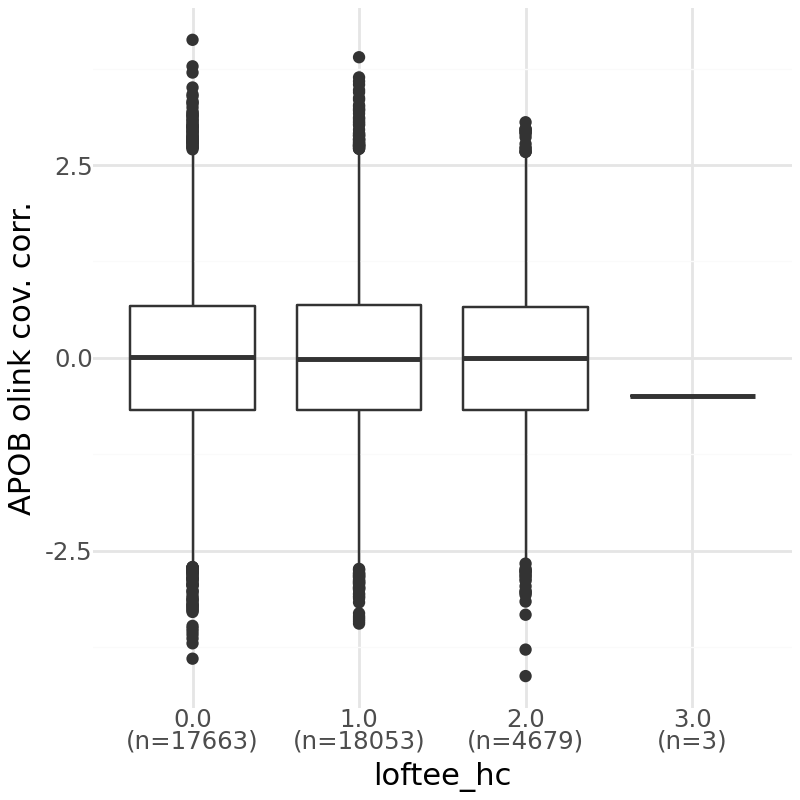

In [124]:
annotation = 'loftee_hc'

plot_df = (
    burden_df
    .filter(
        (pl.col('annotation') == annotation)
    )
)

summary_labels = (
    plot_df
    .group_by(['gene_burden'])
    .agg(n_inds = pl.col('individual').len())
    .with_columns(n_label = pl.col('gene_burden').cast(pl.Utf8) + '\n(n=' + pl.col('n_inds').cast(pl.Utf8) + ')')
)

plot_df = plot_df.join(summary_labels, on='gene_burden', how='left')

(
    ggplot(plot_df, aes(x='n_label', y='olink_value')) +
    geom_boxplot(aes(group='n_label')) +
    theme_minimal() +
    labs(
        x=f"{annotation}",
        y=f"{gene_name} olink cov. corr.",
        # title=f"{plof_vars}/{plot_df['id'].n_unique()} plof variants"
    ) +
    theme(figure_size=(4, 4))
)